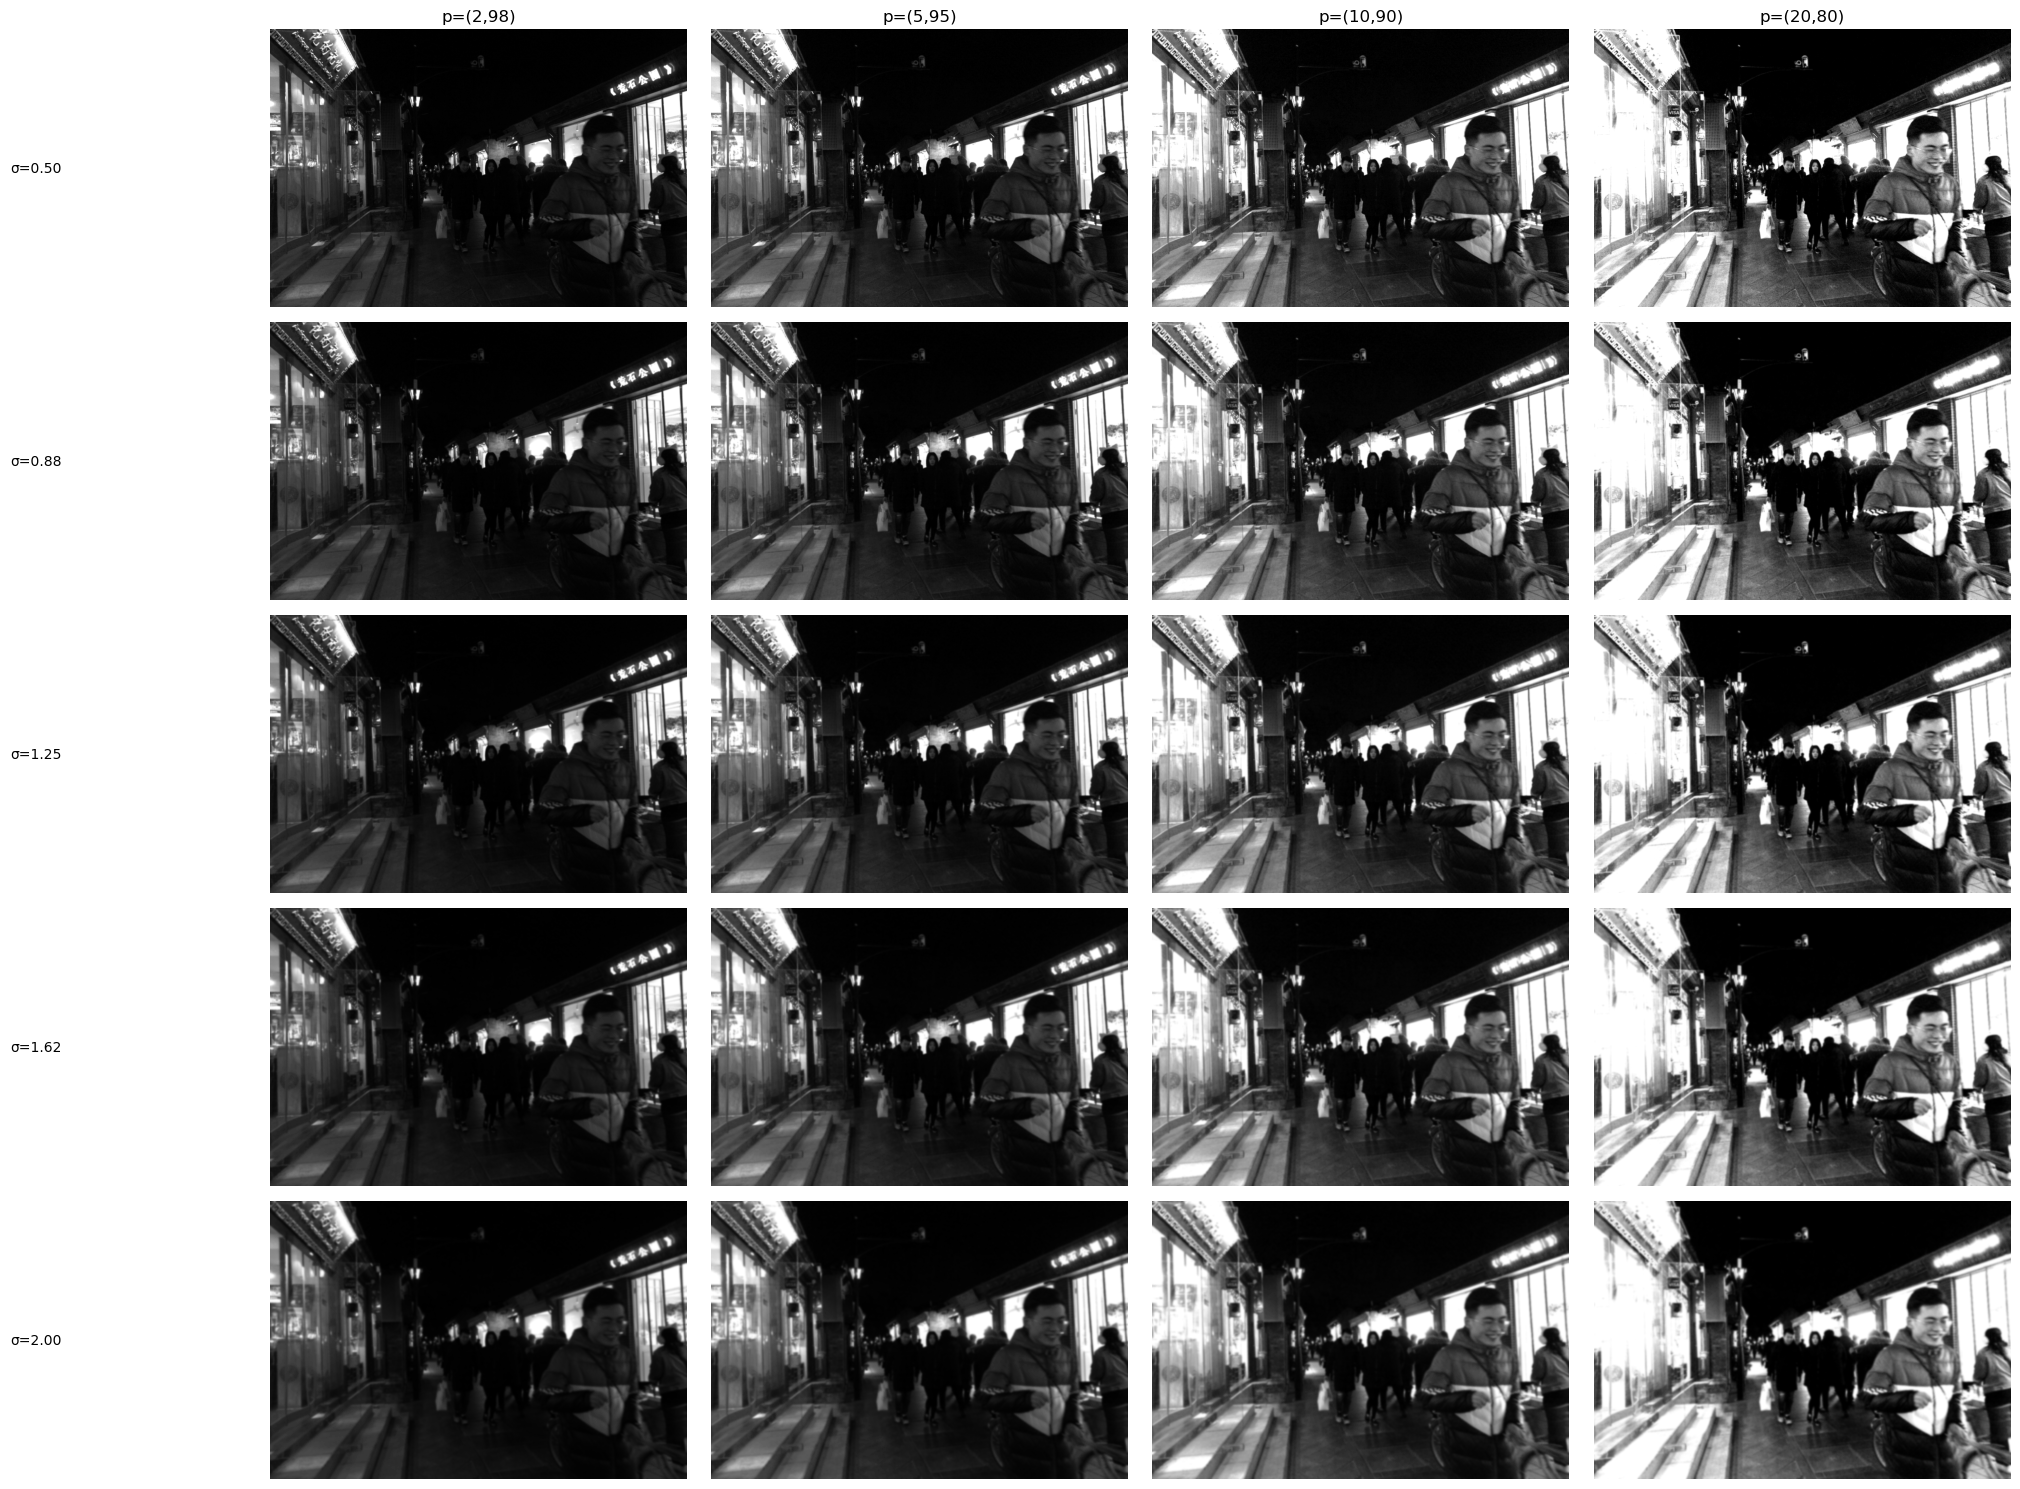

In [1]:
from skimage import io, img_as_float, exposure, filters
import numpy as np
import matplotlib.pyplot as plt

# Ruta de la imagen a procesar
image_path = "1.png"

# Valores de sigma para el filtro Gaussiano
sigma_values = np.linspace(0.5, 2.0, 5)  # 10 valores de sigma

# Combinaciones de percentiles
percentile_combinations = [(2, 98), (5, 95), (10, 90), (20, 80)]  # 4 combinaciones

# Función para contrast stretching
def contrast_stretching(image, min_percentile, max_percentile):
    p2, p98 = np.percentile(image, (min_percentile, max_percentile))
    return exposure.rescale_intensity(image, in_range=(p2, p98))

# Leer la imagen
image = io.imread(image_path, as_gray=True)
image = img_as_float(image)  # Convertir a flotantes normalizados

# Crear figura
fig, axes = plt.subplots(len(sigma_values), len(percentile_combinations), figsize=(20, 15))

# Procesar y graficar
for col, (min_percentile, max_percentile) in enumerate(percentile_combinations):
    # Aplicar Contrast Stretching
    contrast_stretched = contrast_stretching(image, min_percentile, max_percentile)
    
    for row, sigma in enumerate(sigma_values):
        # Aplicar filtro Gaussiano
        smoothed = filters.gaussian(contrast_stretched, sigma=sigma)
        
        # Mostrar imagen procesada
        axes[row, col].imshow(smoothed, cmap='gray')
        axes[row, col].axis('off')
        
        # Etiquetas para valores de sigma
        if col == 0:
            axes[row, col].text(
                -0.5, 0.5, f"σ={sigma:.2f}",
                fontsize=10, va='center', ha='right',
                transform=axes[row, col].transAxes
            )
        if row == 0:
            axes[row, col].set_title(f"p=({min_percentile},{max_percentile})", fontsize=12)

# Ajustar layout
plt.tight_layout()
plt.show()
